# Analysing and Predicting Luxury Watch Prices 


## Skills: Introduction to Programming

# Execute in case not all packages are already installed locally
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install category_encoders
!pip install xgboost
!pip install shap

In [54]:
#Import the relevant libraries for data manipulation and visualization and prediction:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as lg 
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

#### Yannick Allmann, Jan Nemeth (add names)

## Part1: Dataset Loading 

In this section we will be loading the dataset of luxury watches we obtained from Kaggle. We will be using the pandas library to read the dataset and load it into a DataFrame for further analysis.


In [55]:
#Load the datset using the pandas library via Github
watch_data = pd.read_csv("Watches.csv")

#Inspect the first few rows of the dataset
watch_data.head()

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_12117/1283161374.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  watch_data = pd.read_csv("Watches.csv")


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


For the interested reader: ref stands for the reference number of the watch, movm stands for the movement of the watch, casem stands for the case material, bracem stands for the bracelet material, yop stands for the year of production, cond stands for the condition of the watch

Before we start with the cleaning lets descirbe the dataset to get an overview

In [56]:
watch_data.describe()

,Unnamed: 0
count,284491.000000
mean,16027.513369
std,17410.945197
min,0.000000
25%,4199.000000
50%,9211.000000
75%,20556.000000
max,72584.000000


#Add explantion later

## Part 2: Data Cleaning (Missing Values)

As our final goal in these project is to predict the price of the luxury watches we need a complete dataset without any missing values otherwise a machine learning model will not work well. Therefore, we will look at which columns have missing values in the dataset. After identifying the missing values, we will then decide how to handle these missing values, whether we will drop the rows with missing values or fill them with some appropriate values (e.g., mean-based, model-based imputation, etc.).

In [5]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

Unnamed: 0     0.000000
name          25.513988
price          0.142711
brand          0.046047
model         10.708950
ref           15.168142
mvmt          69.135755
casem         57.742073
bracem        61.476813
yop            0.047102
cond          26.709808
sex           33.675934
size           8.294463
condition     74.843141
dtype: float64

We can see that a lot of columns contain a significant amount of missing values, for example the columns condition and movement have roughly 70% missing values. Therefore, we have to make well-informed decisions on how to handle these missing values:

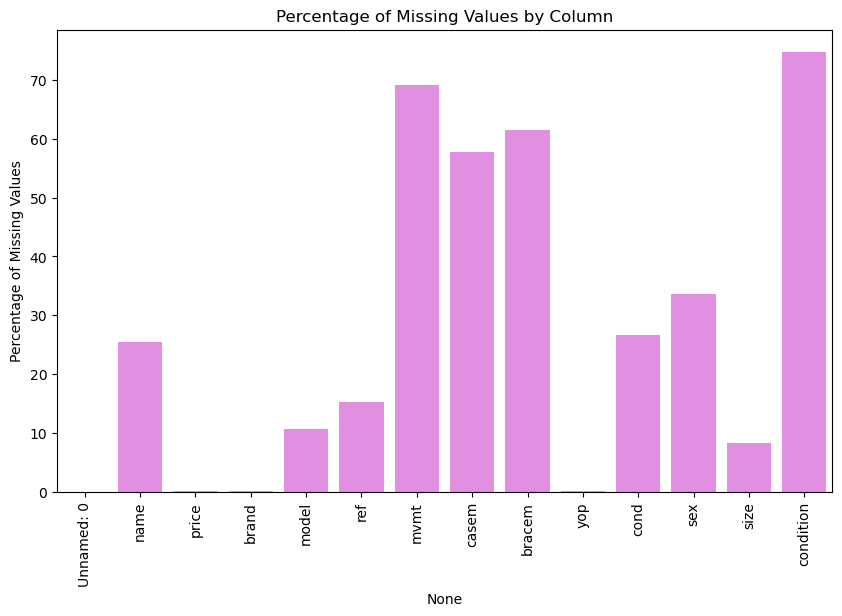

In [6]:
#To Visualize the percentage of missing values by column we can use a bar plot:
#We use seaborn for the bar plot and matplotlib for the figure size and labels
#The index of the missing_values series contains the column names (e.g. brand, model, etc.) and the values of the missing_values series contains the percentage of missing values for each column. T
#xticks refers to the x-axis labels and rotation=90 means that we rotate the labels by 90 degrees to make them more readable

plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='violet')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values by Column')
plt.show()

First of all since Unnamed: 0 is just an index column we will drop it from the dataset. 

In [7]:
#Drop the Unnamed:0 column
watch_data = watch_data.drop(columns=['Unnamed: 0'])

Since name is just a composite of the brand and the model of the watch we will also drop this column from the dataset since it does not provide any additional information for our analysis.

In [8]:
#Drop the name column 
watch_data = watch_data.drop(columns=['name'])

Next the reference numbers does not provide any  information for our analysis and contains missing values as well, therefore we will also drop this column from the dataset.
 

In [9]:
#Drop the reference column: 
watch_data = watch_data.drop(columns=['ref'])

Furthermore we can see that we have 2 condition columns in the dataset, cond and condition. In the original head, the cond contained information, while condition did not contain information (only NaNs). The cond column also has less NaNs, so we are tempted to delete the condition column. First we want to check if we dont lose any information from this however.

In [10]:
# Look for rows where 'cond' is NaN AND 'condition' is NOT NaN
risk_rows = watch_data[watch_data['cond'].isna() & watch_data['condition'].notna()]

print(f"Number of rows at risk of losing data: {len(risk_rows)}")
display(risk_rows[['cond', 'condition']].head())

Number of rows at risk of losing data: 71569


,cond,condition
151509,NaN,Very good
151510,NaN,Very good
151511,NaN,Very good
151512,NaN,Unworn
151513,NaN,Unworn


As you can see, we would actually lose over 70'000 Rows of information if we would delete this column, as it has information when the cond column does not. Next we want to check if we have an overlap of rows, where both columns have information but they are not the same.

In [11]:
# Look for rows where both have data, but the values don't match
conflict_rows = watch_data[watch_data['cond'].notna() & watch_data['condition'].notna() & (watch_data['cond'] != watch_data['condition'])]

print(f"Number of conflicting rows: {len(conflict_rows)}")

Number of conflicting rows: 0


As it turns out, we are in luck as there are no conflicting values. This means we can use data from either the cond and the condition column and they dont change the value, if there is a value. This menas we just add the condition column to the cond column if there is information in the Condition column but not the cond column. 

In [12]:
# Fill the NaNs in 'cond' with the values from 'condition'
watch_data['cond'] = watch_data['cond'].fillna(watch_data['condition'])


Now that we dont lose any information we can delete the condition column

In [13]:
# now it is safe to drop the 'condition' column
watch_data = watch_data.drop(columns=['condition'])

In [14]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

price      0.142711
brand      0.046047
model     10.708950
mvmt      69.135755
casem     57.742073
bracem    61.476813
yop        0.047102
cond       1.552949
sex       33.675934
size       8.294463
dtype: float64

We now only have missing values in 1.5% of the condition rows.

We can see that all of the variables are of the general type object. We want to give them more specific datatypes (e.g. int, float, strings), but this is tricky because the numbers contain special letters like mm and $.



In [15]:
#For the numeric columns we have to be more precise for instance look at size column unique values with pd.unique first: 
(watch_data['price']).unique()

array(['$43,500', '$71,500', '$79,191', ..., '$18,245', '$20,068',
       '$32,108'], dtype=object)

In [16]:
pd.unique(watch_data['size'])

array(['42 mm', '39 mm', '41 mm', ..., '40 x 10.75 mm', '46 x 17 mm',
       '48 x 57.5 mm'], dtype=object)

To solve this we will clean the data in the next step


## Part 3: Data Cleaning (Datatypes)

**Datatypes of the variables in the dataset:**

In [17]:
#Overview of the datatypes of the variables in the dataset after cleaning:
watch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   price   284085 non-null  object
 1   brand   284360 non-null  object
 2   model   254025 non-null  object
 3   mvmt    87806 non-null   object
 4   casem   120220 non-null  object
 5   bracem  109595 non-null  object
 6   yop     284357 non-null  object
 7   cond    280073 non-null  object
 8   sex     188686 non-null  object
 9   size    260894 non-null  object
dtypes: object(10)
memory usage: 21.7+ MB


With pandas info() function we can get an overview of the datatypes of the variables in the dataset. Note that object is the general datatype for string variables in pandas. For the numeric columns like price, size and year of production we will convert them to numeric datatypes (e.g. int or float). But lets first inspect the unique values of this features to see if there are any issues with the datatypes 

In [18]:
#Unique values of the size column:
watch_data['size'].unique()


array(['42 mm', '39 mm', '41 mm', ..., '40 x 10.75 mm', '46 x 17 mm',
       '48 x 57.5 mm'], dtype=object)

We have an issue here because sometimes the size is just one number and sometimes its two, so we can not just drop the rest of the string after the first two numbers and convert it. In order to solve this we have to extract the numbers and take the more reasonable for size. since the majority of sizes is between 30 and 50, we prefer a number that is above 20 and below 60. We only store one int in mm for each observation, because the majority only has one. 

In [19]:
# Initialize a list to store the final processed case sizes
cleaned_sizes = []

# Iterate through the raw dimension strings, handling potential missing data first
for val in watch_data['size'].astype(str):
    if val.lower() == 'nan' or val.lower() == 'none' or val.strip() == '':
        cleaned_sizes.append(None)
        continue
        
    # Normalize the string by removing common units and splitting multiple dimensions
    parts = val.lower().replace('mm', '').split('x')
    
    # Sanitize the data: iterate through each dimension to filter out unexpected characters
    nums = []
    for p in parts:
        clean_p = p.strip()
        
        # Build a clean string character-by-character to discard symbols like superscripts
        sanitized = ""
        for char in clean_p:
            if char in "0123456789.":
                sanitized += char
                
        try:
            # Convert the sanitized string into a float for mathematical comparison
            if sanitized != "":
                nums.append(float(sanitized))
        except ValueError:
            pass
            
    # Apply domain-specific logic to isolate the case diameter from thickness or lug-to-lug measurements
    if len(nums) == 0:
        cleaned_sizes.append(None)
    else:
        low_val = min(nums)
        high_val = max(nums)
        
        if low_val < 25:
            # Filter out case thickness (typically < 25mm)
            chosen_size = high_val
        elif high_val > 50:
            # Filter out lug-to-lug or strap lengths (typically > 50mm)
            chosen_size = low_val
        else:
            # Default assumption: case diameter is the largest standard measurement
            chosen_size = high_val
            
        # SANITY CHECK: Prevent OverflowErrors from massive garbage numbers (like serial numbers)
        if chosen_size > 100:
            cleaned_sizes.append(None)
        else:
            # Apply standard arithmetic rounding (half-up) and cast to integer
            cleaned_sizes.append(int(chosen_size + 0.5))

# Reassign the cleaned data directly as a pandas nullable integer array
watch_data['size'] = pd.array(cleaned_sizes, dtype='Int64')


# Count how many rows have a missing 'size' and store it in the variable
NA_Rows = watch_data['size'].isna().sum()

# Print the KPI and the head of the DataFrame
print(f"Total rows with no size value after cleaning: {NA_Rows}")

# Show the top 15 most common and 5 least common entries in the raw 'size' column 
display(watch_data['size'].value_counts(dropna=False).head(15))
display(watch_data['size'].value_counts(dropna=False).tail(5))

Total rows with no size value after cleaning: 26361


size
40      39305
41      32603
42      29716
<NA>    26361
36      21026
44      19130
39      14172
43      12241
38       9022
45       9002
34       8744
35       6690
37       6603
26       5490
31       5240
Name: count, dtype: Int64

size
63    1
91    1
79    1
73    1
96    1
Name: count, dtype: Int64

These sizes now seem reasonable. We will not drop NAs until the end when we do another step to minimize dropping rows.

In [20]:
# Show the top 15 most common and 5 least common entries in the raw 'yop' column 
display(watch_data['yop'].value_counts(dropna=False).head(15))
display(watch_data['yop'].value_counts(dropna=False).tail(5))


yop
Unknown                 95957
2023                    49227
2022                    20654
2021                    10501
2023 (Approximation)     6136
2020                     5573
2019                     4501
2022 (Approximation)     4132
2018                     3781
2017                     2877
2016                     2609
2015                     2235
1970 (Approximation)     2112
2014                     1927
2010                     1915
Name: count, dtype: int64

yop
1960, 1968, 1975        1
1852 (Approximation)    1
2016, 2017, 2018        1
2007, 2010, 2012        1
1650 (Approximation)    1
Name: count, dtype: int64

The same logic applies here for the year of production. We are interested in the first 4 numeric year characters of the string. Therefore we will slice the year of production column to keep only the first 4 characters and then convert it to int. We remove "(Approximation)" and the unknowns

In [21]:
# Store the amount of "Unknown" in a variable for later comparison
unknown_count = (watch_data['yop'] == 'Unknown').sum()
unknown_count

95957

In [22]:
# 1. Create a temporary list to hold our results 
results = []

for index, row in watch_data.iterrows():
    original_val = str(row['yop'])
    
    # Skip standard blanks and "Unknown" 
    if original_val.lower() in ['nan', 'none', '<na>', "unknown", '']:
        results.append(None)
        continue
        
    short_val = original_val.strip()[:4]
    
    # Initialize variables for our logic checks
    is_problem = False
    
    try:
        parsed_year = int(short_val)
        
        # Check for logic errors (years too low or in the future)
        if parsed_year < 1500 or parsed_year > 2026:
            is_problem = True
            results.append(None)
            
    except ValueError:
        # Check for format errors (text, weird symbols)
        is_problem = True
        results.append(None)

    # If it's clean, append and move on
    if not is_problem:
        results.append(parsed_year)
        
   


# 2. Update the main DataFrame 
watch_data['yop'] = pd.array(results, dtype='Int64')

# Count how many rows have a missing 'size' and store it in the variable
NA_Rows = watch_data['yop'].isna().sum()

# Print the KPI and the head of the DataFrame
print(f"Total rows with no yop value after cleaning: {NA_Rows}, of which {unknown_count} were already unknown")

# Show the top 15 most common and 5 least common entries in the raw 'yop' column 
display(watch_data['yop'].value_counts(dropna=False).head(15))
display(watch_data['yop'].value_counts(dropna=False).tail(5))

Total rows with no yop value after cleaning: 96091, of which 95957 were already unknown


yop
<NA>    96091
2023    55363
2022    24797
2021    12435
2020     6950
2019     5615
2018     4717
2017     3574
2000     3295
2016     3211
1970     3194
2015     2922
2010     2881
1990     2736
2014     2295
Name: count, dtype: Int64

yop
1694    1
1852    1
1690    1
1878    1
1885    1
Name: count, dtype: Int64

Next we will look at the unique values of the price column to see if there are any issues with the datatypes in this column as well.

In [23]:
# Show the top 10 most common and 3 least common entries in the raw 'price' column 
display(watch_data['price'].value_counts(dropna=False).head(10))
display(watch_data['price'].value_counts(dropna=False).tail(3))

price
Price on request    14259
NaN                   406
$6,500                255
$12,500               251
$4,500                240
$4,026                239
$8,500                232
$5,500                227
$5,176                221
$7,500                219
Name: count, dtype: int64

price
$34,624     1
$825,000    1
$43,329     1
Name: count, dtype: int64

In [24]:
# First, calculate how many "Price on request" entries we are starting with
price_on_request_count = (watch_data['price'] == 'Price on request').sum()

# 1. Create a temporary list to hold our results 
results = []

for index, row in watch_data.iterrows():
    original_val = str(row['price'])
    
    # Skip standard blanks and "Price on request" 
    if original_val.lower() in ['nan', 'none', '<na>', 'price on request', '']:
        results.append(None)
        continue
        
    # Remove the dollar signs, commas, and extra spaces
    clean_val = original_val.replace('$', '').replace(',', '').strip()
    
    # Initialize variables for our logic checks
    is_problem = False
    
    try:
        # We parse as float, since decimal numbers are okay here
        parsed_price = float(clean_val)
        
        # Check for logic errors (e.g., negative prices or a price of 0)
        if parsed_price <= 0:
            is_problem = True
            results.append(None)
            
    except ValueError:
        # Check for format errors (text, weird symbols we didn't catch)
        is_problem = True
        results.append(None)

    # If it's clean, append and move on
    if not is_problem:
        results.append(parsed_price)

# 2. Update the main DataFrame 
watch_data['price'] = pd.array(results, dtype='Float64')

# Count how many rows have a missing 'price' and store it in the variable
NA_Rows = watch_data['price'].isna().sum()

# Print the KPI 
print(f"Total rows with no price value after cleaning: {NA_Rows}, of which {price_on_request_count} were 'Price on request'")

# Show the top 15 most common and 5 least common entries in the cleaned 'price' column 
display(watch_data['price'].value_counts(dropna=False).head(15))
display(watch_data['price'].value_counts(dropna=False).tail(5))

Total rows with no price value after cleaning: 14665, of which 14259 were 'Price on request'


price
<NA>       14665
6500.0       255
12500.0      251
4500.0       240
4026.0       239
8500.0       232
5500.0       227
5176.0       221
7500.0       219
3500.0       215
11850.0      214
3450.0       213
5750.0       211
9500.0       207
11500.0      204
Name: count, dtype: Int64

price
15992.0     1
825000.0    1
54330.0     1
104020.0    1
43329.0     1
Name: count, dtype: Int64

In [25]:
watch_data.dtypes

price     Float64
brand      object
model      object
mvmt       object
casem      object
bracem     object
yop         Int64
cond       object
sex        object
size        Int64
dtype: object

In [26]:
summary_rows = []

for col in watch_data.columns:
    # Get the full value counts, including NaNs
    counts = watch_data[col].value_counts(dropna=False)
    
    # Extract top 5 and bottom 3
    top_5 = counts.head(5)
    bottom_3 = counts.tail(3)
    
    # Format them into readable strings like "Value (Count), Value (Count)"
    top_str = ", ".join([f"{val} ({count})" for val, count in top_5.items()])
    bottom_str = ", ".join([f"{val} ({count})" for val, count in bottom_3.items()])
    
    # Append to our summary list
    summary_rows.append({
        'Column Name': col,
        'Total Unique': len(counts),
        'Top 5 (Counts)': top_str,
        'Bottom 3 (Counts)': bottom_str
    })

# Convert the list to a DataFrame
summary_df = pd.DataFrame(summary_rows)

# Optional: This pandas setting ensures the long text wraps nicely in your notebook
# rather than truncating with "..."
with pd.option_context('display.max_colwidth', None):
    display(summary_df)

,Column Name,Total Unique,Top 5 (Counts),Bottom 3 (Counts)
0,price,36830,"<NA> (14665), 6500.0 (255), 12500.0 (251), 4500.0 (240), 4026.0 (239)","54330.0 (1), 104020.0 (1), 43329.0 (1)"
1,brand,29,"Rolex (72484), Omega (39631), Seiko (19297), Breitling (18066), Cartier (16607)","Meistersinger (1), Rado (1), Ebel (1)"
2,model,949,"nan (30466), Datejust 36 (9473), Daytona (7406), Datejust 41 (6361), Submariner Date (5296)","Jazzmaster Viewmatic (1), Artelier Translucent Skeleton (1), 456 (1)"
3,mvmt,4,"nan (196685), Automatic (65600), Quartz (14615), Manual winding (7591)","Automatic (65600), Quartz (14615), Manual winding (7591)"
4,casem,18,"nan (164271), Steel (75793), Gold/Steel (11031), Rose gold (9320), Yellow gold (7875)","Tantalum (23), Palladium (14), Tungsten (3)"
5,bracem,24,"nan (174896), Steel (49605), Leather (15657), Rubber (11271), Gold/Steel (10030)","Silver (13), Aluminium (9), Shark skin (9)"
6,yop,170,"<NA> (96091), 2023 (55363), 2022 (24797), 2021 (12435), 2020 (6950)","1690 (1), 1878 (1), 1885 (1)"
7,cond,8,"Very good (107740), New (77337), Unworn (50302), Good (35682), Fair (8774)","nan (4418), Poor (193), Incomplete (45)"
8,sex,3,"Men's watch/Unisex (158841), nan (95805), Women's watch (29845)","Men's watch/Unisex (158841), nan (95805), Women's watch (29845)"
9,size,86,"40 (39305), 41 (32603), 42 (29716), <NA> (26361), 36 (21026)","79 (1), 73 (1), 96 (1)"


This check over all columns shows intact values, as we dont expect anything else and they are clean (i.e. no "approximation" added behind)

In [27]:
# Print NAs per column, then print the total number of rows containing at least one NA
print("--- NAs Per Column ---")
print(watch_data.isna().sum())
print(f"\nTotal rows with at least one NA: {watch_data.isna().any(axis=1).sum()}")
NA_rows_before = watch_data.isna().any(axis=1).sum()
print(f"Total rows: {NA_rows_before}")

--- NAs Per Column ---
price      14665
brand        131
model      30466
mvmt      196685
casem     164271
bracem    174896
yop        96091
cond        4418
sex        95805
size       26361
dtype: int64

Total rows with at least one NA: 249500
Total rows: 249500


We need to drop all NAs in the price, as this will be our target in the machine learning and we can not have NA there.

In [28]:
#The dropna function is used to drop rows with missing values in the specified columns (specified by argument subset).
watch_data = watch_data.dropna(subset=['price'])

In [29]:
#Check missing values again:
watch_data.isna().mean() * 100 

price      0.000000
brand      0.000000
model     10.884792
mvmt      69.027077
casem     57.795765
bracem    61.654548
yop       33.718026
cond       1.384225
sex       33.416720
size       9.095862
dtype: float64

In [30]:
#Finally, lets rename our variables to make them more intuitive and easier to work with:
#We can use the rename method from pandas for this 
watch_data_cleaned = watch_data.rename(columns={'mvmt': 'movement', 'bracem': 'bracelet_material', 'casem': 'case_material', 'cond': 'condition'})

In [31]:
watch_data_cleaned

,price,brand,model,movement,case_material,bracelet_material,yop,condition,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39
2,79191.0,Audemars Piguet,Royal Oak Chronograph,Automatic,Steel,Steel,<NA>,Unworn,NaN,41
3,108000.0,Audemars Piguet,Royal Oak Chronograph,Automatic,Steel,Steel,2022,New,Men's watch/Unisex,38
4,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,Automatic,Steel,Steel,<NA>,Very good,Men's watch/Unisex,42
...,...,...,...,...,...,...,...,...,...,...
284486,9790.0,Zenith,Defy El Primero,NaN,NaN,NaN,2022,Very good,Men's watch/Unisex,44
284487,8450.0,Zenith,Chronomaster Sport,NaN,NaN,NaN,2021,Very good,Men's watch/Unisex,41
284488,16500.0,Zenith,El Primero,NaN,NaN,NaN,2019,Very good,Men's watch/Unisex,38
284489,9000.0,Zenith,Chronomaster Sport,NaN,NaN,NaN,2021,Unworn,Men's watch/Unisex,41


## Part 4: Exploratory Data Analysis (EDA)

### 4.1. Price Variable

In this section we want to understand our dataset better and get some insights about the distribution and relationships of variables in the dataset in order to understand if we need to apply any transformations or if there are any outliers that might affect our model. First of all we will look at the distribution of the price variable since this is our main target variable 

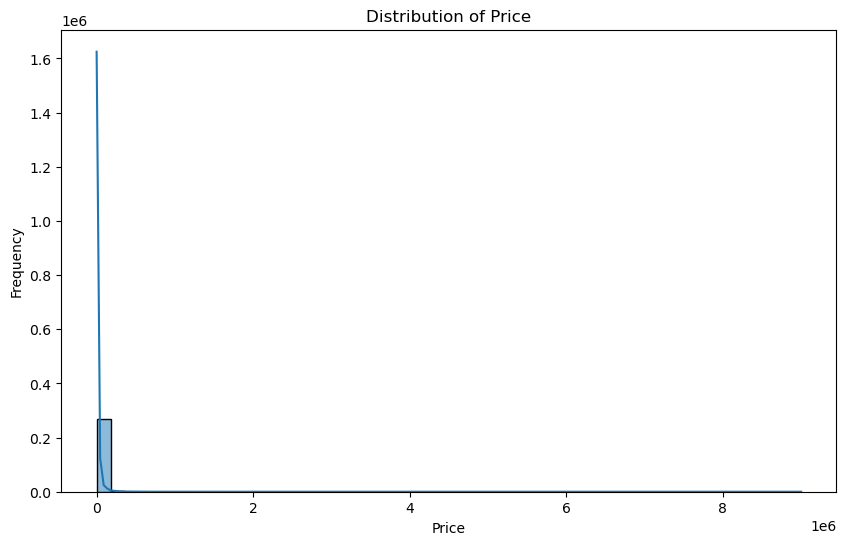

In [32]:
#To plot the distribution of the price variable we use the seaborn library and the histplot function to plot a histogram of the  price variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price') 
plt.ylabel('Frequency')
plt.show()

We can see that the distribution of the price variable is highly right skewed (driven by really expensive outliers) and not normally distributed. Our basic statistics and data science knowledge tells us that a log transformation could potentialy bring the distribution closer to a normal distribution. Lets try this out: 

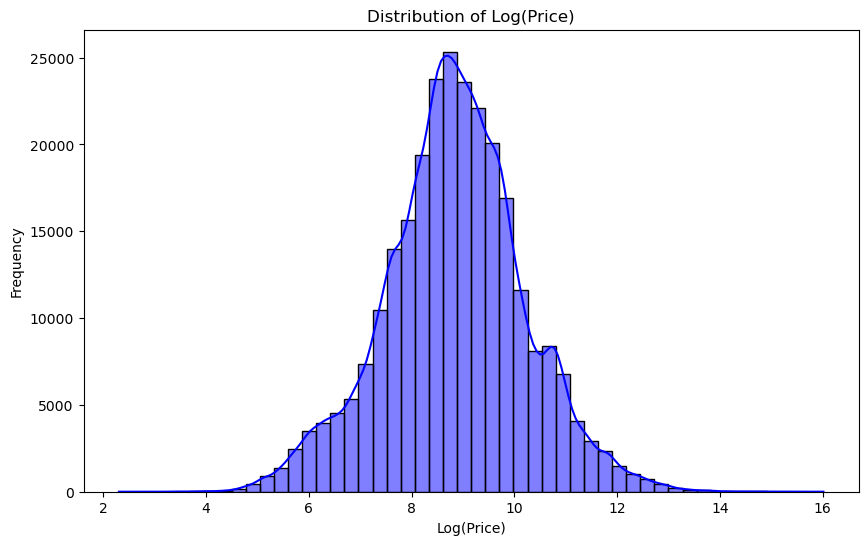

In [33]:
#Distribution of the log price variable:
#np.log is a numpy function that applies the natural logarithm to the values in the price column. 

plt.figure(figsize=(10,6))
sns.histplot(np.log(watch_data_cleaned['price']), bins=50, kde=True, color='blue')
plt.title('Distribution of Log(Price)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

We can see that the log price is having a better approximation to a normal distribution than the price variable. Therefore, we will be using the log price as our target variable for the prediction task in this project.

Furthermore, we are interested into the price ranges of our dataset. For this we will group the dataset according to 3 categories of price ranges (low, medium and high) and look at a bar plot to see how many observations we have in each price range category.



/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_12117/550754566.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='viridis')


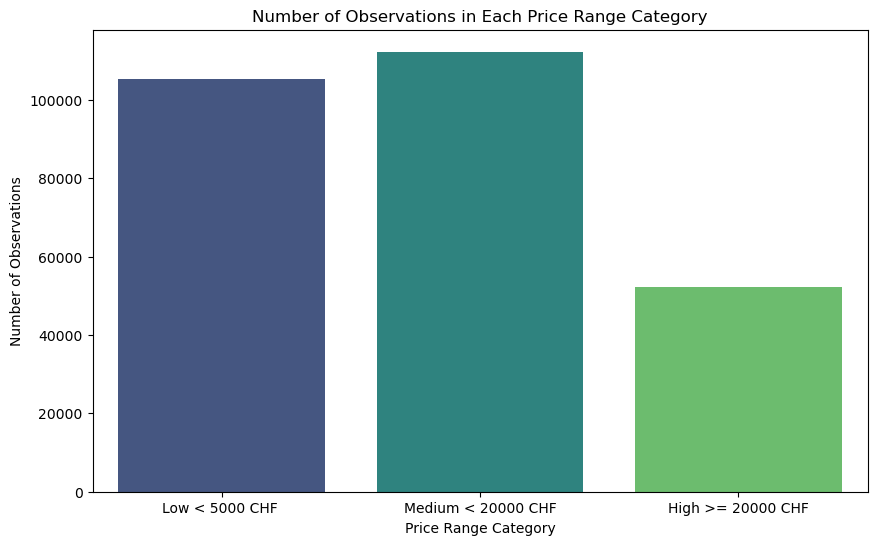

In [34]:
#Define 3 ctaegories in the dataset by filter with boolen masking according to the price variable:
#For the medium category we have to use the & operator to combine the two conditions for the price variable (price < 20000 and price >= 5000) 


category_low = watch_data_cleaned[watch_data_cleaned['price'] < 5000]
category_medium = watch_data_cleaned[(watch_data_cleaned['price'] < 20000) & (watch_data_cleaned['price'] >= 5000)]
category_high = watch_data_cleaned[watch_data_cleaned['price'] >= 20000]


#plot the categories in a bar plot to see how many observations we have in each price range category:
#To do this we will create a list of the categories and a list of the counts (with length function) of observations in each category
#Then we use the seaborn barplot function to plot the categories on the x-axis and the counts on the y-axis.

categories = ['Low < 5000 CHF ', 'Medium < 20000 CHF', 'High >= 20000 CHF']
counts = [len(category_low), len(category_medium), len(category_high)]
plt.figure(figsize=(10,6))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title('Number of Observations in Each Price Range Category')
plt.xlabel('Price Range Category')
plt.ylabel('Number of Observations')
plt.show()

We can see that most of our dataset is concentrated in the medium category. There are also a signficant amount of observations in the low category and a smaller amount of observations in the high category. This is important to know for our prediction task since it means that our model will have more data to learn from in the low/medium price range than in the high price range. 

### 4.2. Brand Variable

Next up, we are interested in the distribution of the brand variable in our dataset. For this we will look at a bar plot to see how many observations we have for each brand in the dataset.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_12117/2025809084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_brands.index, y=unique_brands.values, palette='viridis')


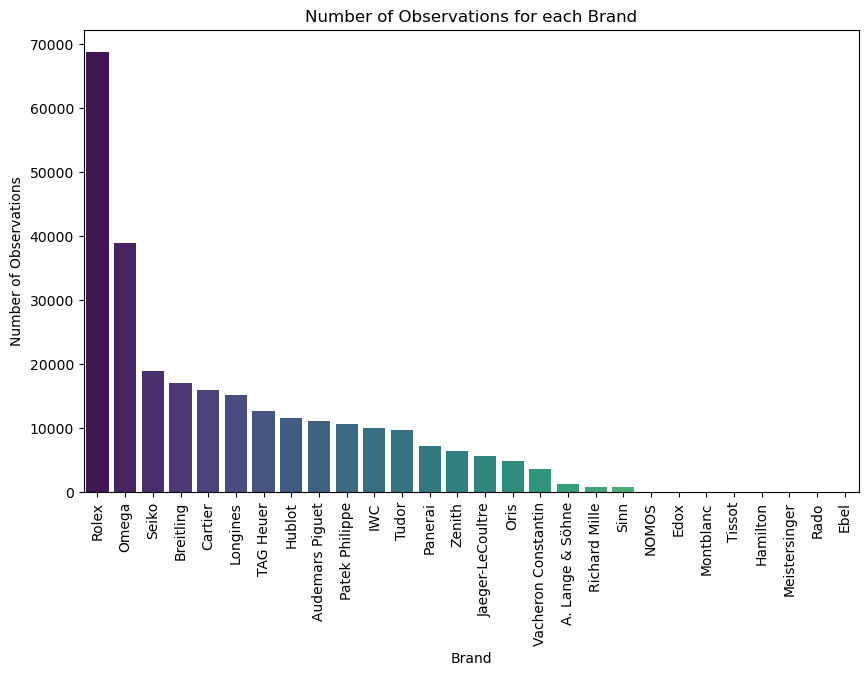

In [35]:
#With value_counts we get the nunique brand names as well as the occurence of each brandname 

unique_brands = watch_data_cleaned['brand'].value_counts()


#We will plot the unique brands using the index attribute for the name of the brands as the .values attribute for the corresponding occurence 
#Seaborn barplot is used for the barplot
#We rotate the labels on the x-axis by 90 degrees to make them more readable 

plt.figure(figsize=(10,6))
sns.barplot(x=unique_brands.index, y=unique_brands.values, palette='viridis')
plt.title('Number of Observations for each Brand')
plt.xlabel('Brand')
plt.xticks(rotation=90)
plt.ylabel('Number of Observations')
plt.show()


Most of our dataset is concentrated on the Rolex brand, but Omega and Seiko have also a significant amount of observations in the dataset. 

### 4.3. Model Variable

Next we will look at the the most common watch models in our dataset. For this we will look again at the value counts of the model variable.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_12117/837524898.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models.index, y=models.values, palette='viridis')


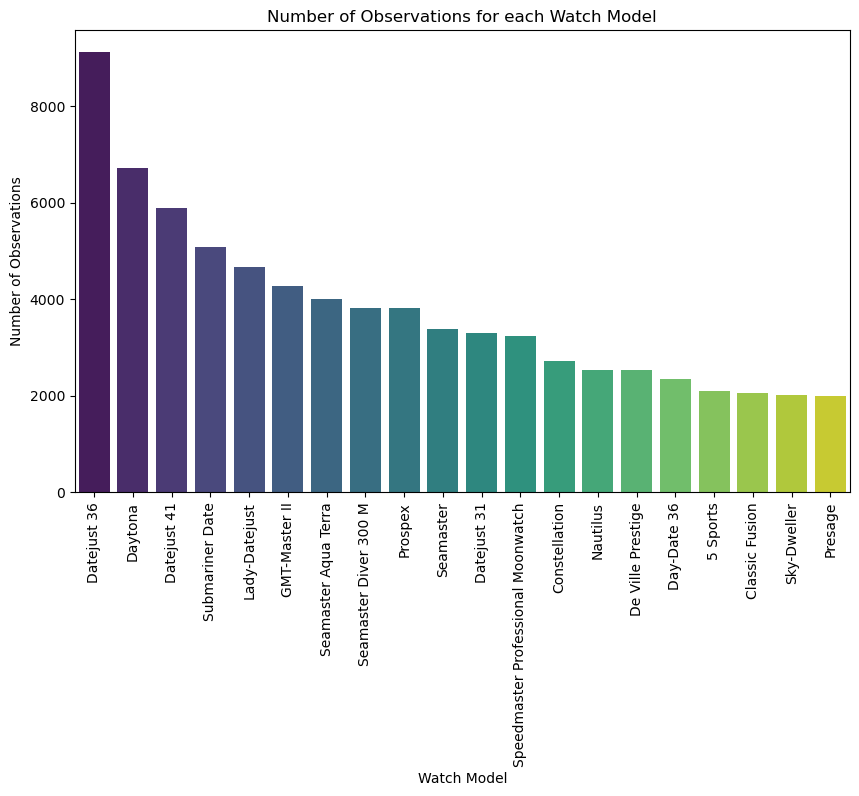

In [36]:
#First of all we again apply the previously described value_counts method 
#Since value counts sorts in descending order with .head(20) we can get the 20 most common watch models in our dataset.
models = watch_data_cleaned['model'].value_counts().head(20)

#We again plot the most common watch models in our dataset using the index attribute for the name of the models as the .values attribute for the corresponding occurence
#Seaborn barplot is used for the barplot
plt.figure(figsize=(10,6))
sns.barplot(x=models.index, y=models.values, palette='viridis') 
plt.title('Number of Observations for each Watch Model')
plt.xlabel('Watch Model')
plt.xticks(rotation=90)
plt.ylabel('Number of Observations')
plt.show()

The most common models stem from the Datejust and Daytona of the Rolex brand. Which is not surprising since we have the most observations from the Rolex brand in our dataset.

### 4.4. Correlation between Variables 

**Size vs log(price)**

In this section we are interested in the relationship between different variables in our dataset. For visualizing the relationship between the different variables we will be using scatter plots for numeric variables.

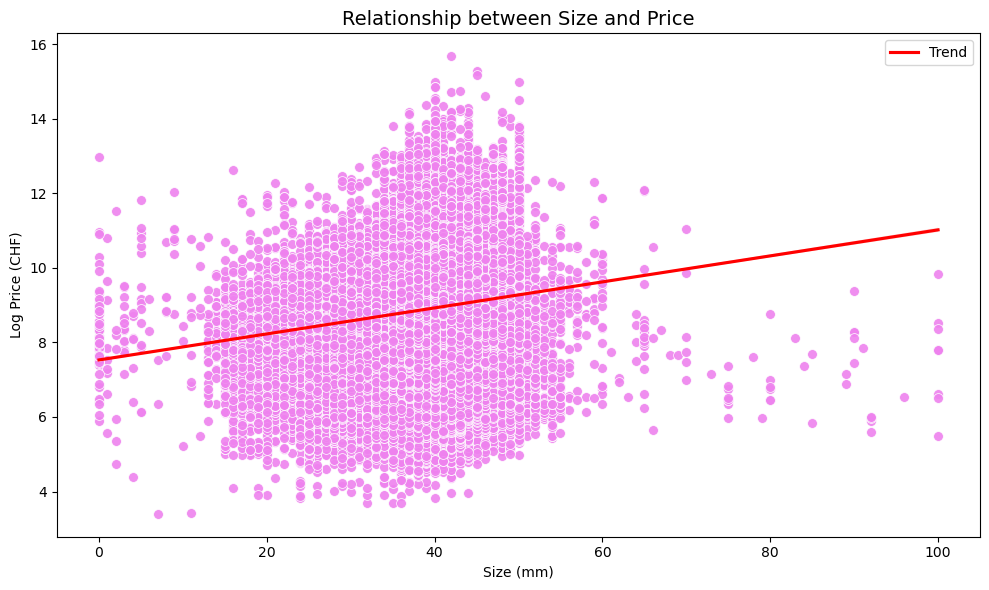

In [37]:
#Plot the relationship between log price and size with a scatter plot:


plt.figure(figsize=(10, 6))

#Scatterplot of size and log price:
# The x-axis of the scatter plot is the size variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.scatterplot(x=watch_data_cleaned['size'], y=np.log(watch_data_cleaned['price']), 
                color='violet', alpha=0.9, s=50)


#Regression Line with seaborn regplot function:
#The x-axis of the regression line is the size variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.regplot(x=watch_data_cleaned['size'], y=np.log(watch_data_cleaned['price']), 
            scatter=False, color='red', label='Trend')


plt.title('Relationship between Size and Price', fontsize=14)
plt.xlabel('Size (mm)')
plt.ylabel('Log Price (CHF)')
plt.legend()
plt.tight_layout()
plt.show()

 Larger watch sizes tend to command higher prices, as shown by the positive trend line. However, the wide spread of points indicates that size alone is a weak predictor of price, suggesting other factors like brand and material play a more significant role. For modeling, this implies that size should not be used as a standalone feature but rather in combination with other variables to improve predictive power (as done in our project)

**Year of production vs log(price)**

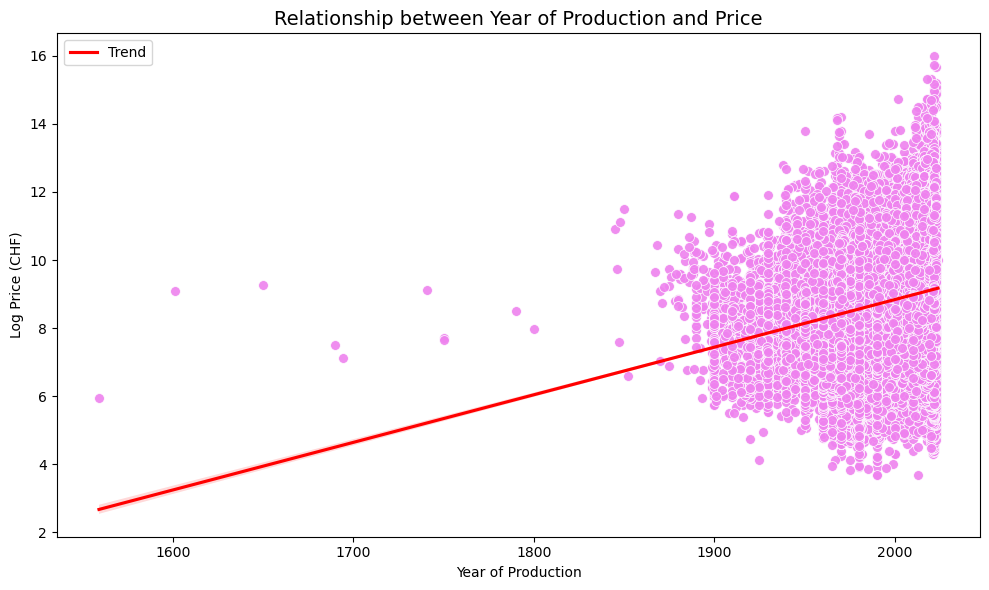

In [38]:
#Plot the relationship between log price and year of production with a scatter plot:


plt.figure(figsize=(10, 6))

#Scatterplot of yop and log price:
# The x-axis of the scatter plot is the yop variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.scatterplot(x=watch_data_cleaned['yop'], y=np.log(watch_data_cleaned['price']), 
                color='violet', alpha=0.9, s=50)


#Regression Line with seaborn regplot function:
#The x-axis of the regression line is the yop variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.regplot(x=watch_data_cleaned['yop'], y=np.log(watch_data_cleaned['price']), 
            scatter=False, color='red', label='Trend')


plt.title('Relationship between Year of Production and Price', fontsize=14)
plt.xlabel('Year of Production')
plt.ylabel('Log Price (CHF)')
plt.legend()
plt.tight_layout()
plt.show()

While more recent watches tend to fetch higher prices overall as shown by the positive trend line, the outliers before 1900 reaching log prices above regression line reveal that rare vintage and antique pieces can also command very high prices. As standalone year of production is likely a weak predictor of price 

**brand vs log(price)**

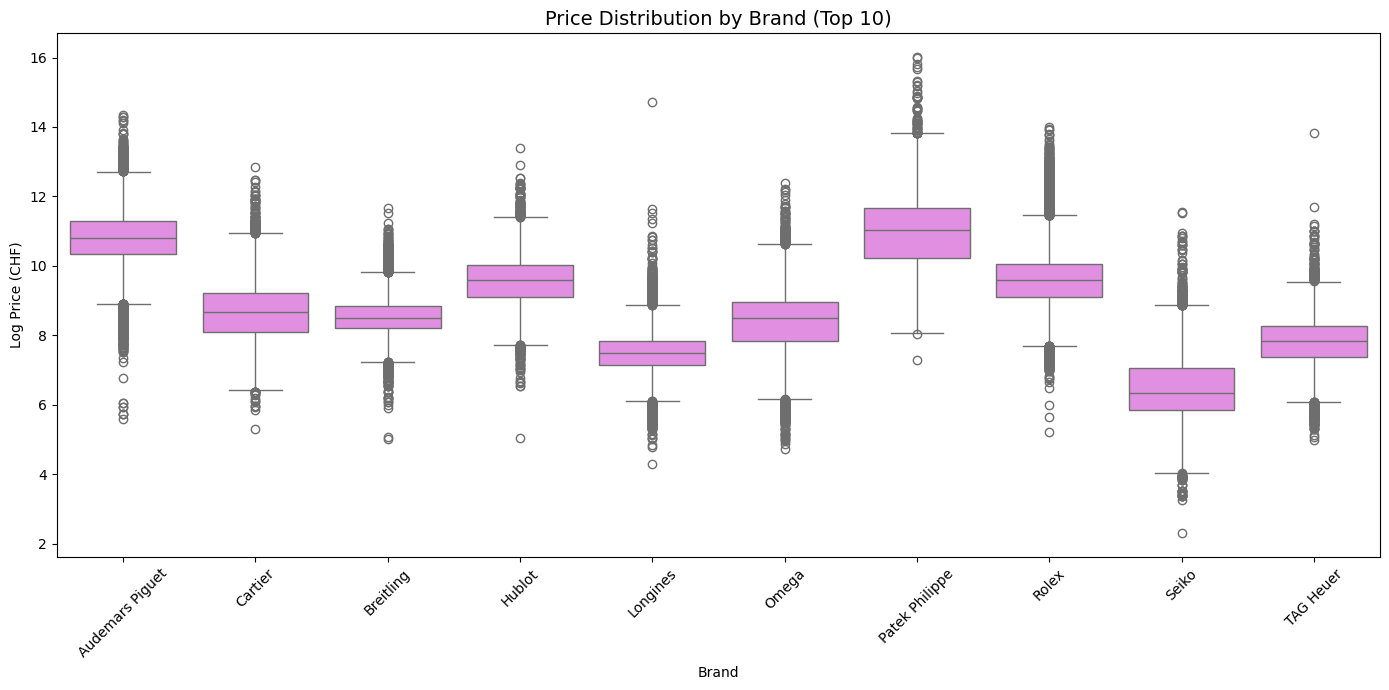

In [39]:
#We will look a the relationship between the price variable and the brand variable with a boxplot:
#First of all we get the top 10 most common brands in our dataset with value_counts and head(10) 
top_10_brands = watch_data_cleaned['brand'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common brands in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['brand'].isin(top_10_brands)], 
            x='brand', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand (Top 10)', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

Patek Philippe and Audemars Piguet clearly occupy the ultra-luxury segment with the highest median prices and wide distributions, while Seiko and Longines sit at the more accessible end of the spectrum. The large spread within most brands indicates that even within a single brand, price varies enormously depending on the model and condition, confirming that brand alone is a strong but insufficient predictor of price.

**case and bracelet material vs log(price)**

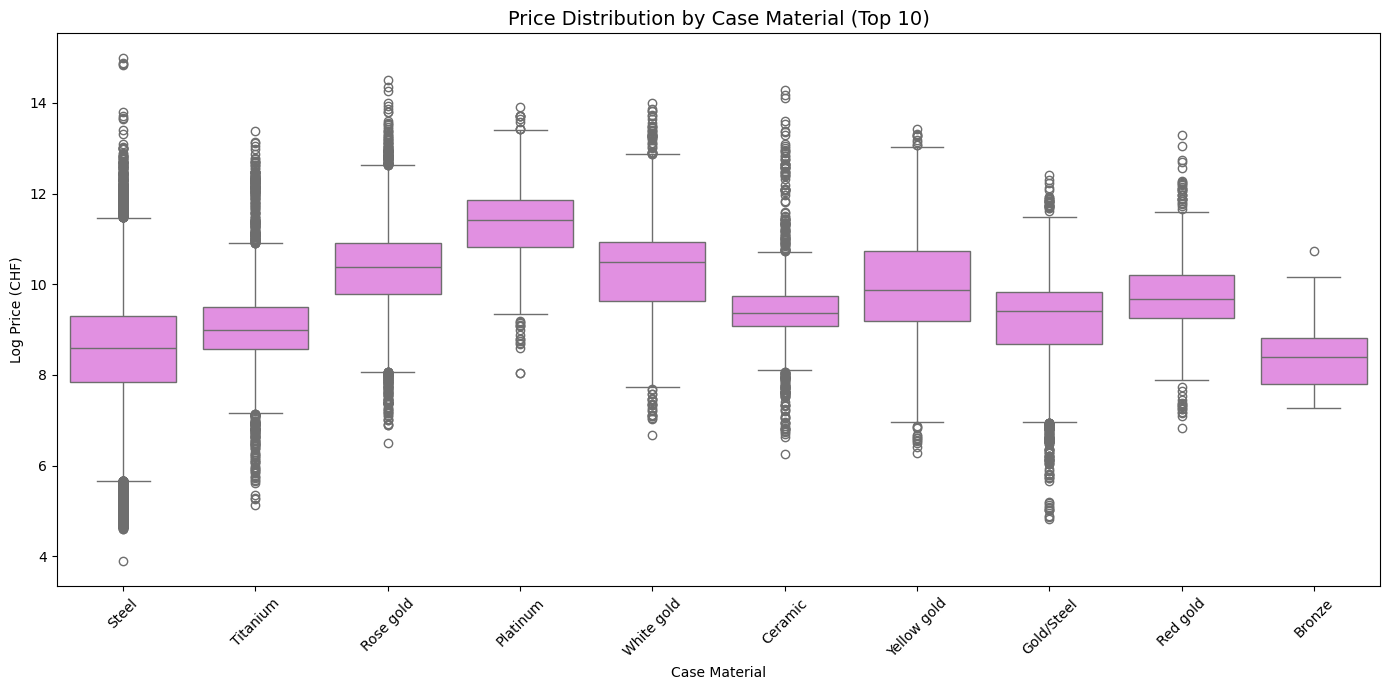

In [40]:
#We will look a the relationship between the price variable and the case_material variable with a boxplot:
#First of all we get the top 10 most common case materials in our dataset with value_counts and head(10) 
top_10_case_materials = watch_data_cleaned['case_material'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common case materials in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['case_material'].isin(top_10_case_materials)], 
            x='case_material', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Case Material (Top 10)', fontsize=14)
plt.xlabel('Case Material')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

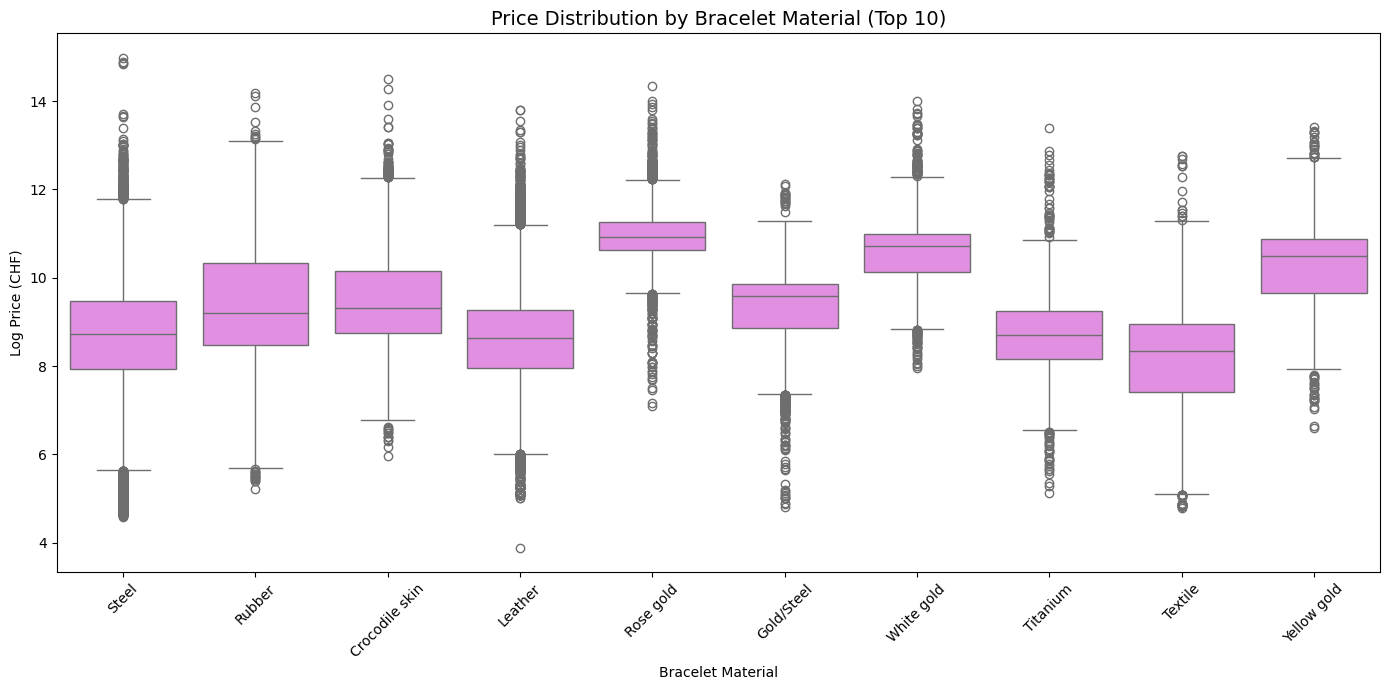

In [41]:
#We will look a the relationship between the price variable and the bracelet_material variable with a boxplot:
#First of all we get the top 10 most common bracelet materials in our dataset with value_counts and head(10) 
top_10_bracelet_materials = watch_data_cleaned['bracelet_material'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common bracelet materials in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['bracelet_material'].isin(top_10_bracelet_materials)], 
            x='bracelet_material', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Bracelet Material (Top 10)', fontsize=14)
plt.xlabel('Bracelet Material')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

**Case Material:** Precious metals like platinum, white gold and rose gold command significantly higher median prices than steel, which despite being the most common material spans a very wide price range. This confirms that case material is a strong price signal and will likely be a valuable feature in modeling.

**Bracelet Material:** Rose gold bracelets stand out with the highest median price, while steel and titanium sit at the lower end. Interestingly the differences between bracelet materials are less pronounced than for case materials,

**Condition vs log(price)**

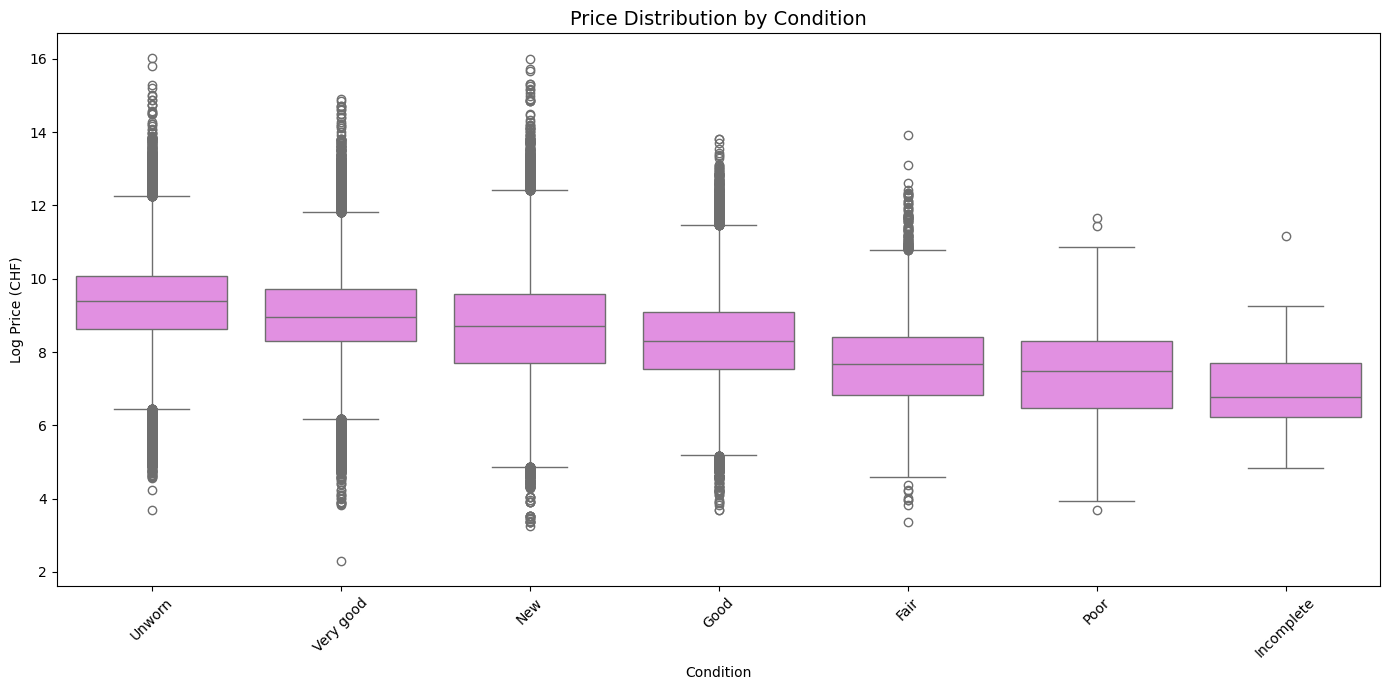

In [42]:
#Boxplot using seaborn boxplot function:
#Condition has only 7 different values in the dataset so we do not have to filter for the top 10 most common conditions in our dataset
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned,
            x='condition', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Condition', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

Even if new watches seem to have a similar price to "Very Good" watches, the overall trend is clear and consistent with market expectations that better condition correlates with higher prices. This suggests that condition should be included as a key feature in our model

## Part 5: Data Preprocessing

In this section we preprocess some findings that we made in the EDA section. For example, we will apply the log transformation to the price variable.

In [43]:
#Transform the price variable with a log transformation
watch_data_cleaned['log_price'] = np.log(watch_data_cleaned['price'])

#Afterwards, we can drop the normal price variable since we have the log price variable now: 
watch_data_cleaned = watch_data_cleaned.drop(columns=['price'])

Our machine learning approach can handle NA values. For numerical values we leave it as NaN, for categorical we just fill all NAs up with Unknown, so the ML will know it is Unknown and we can make it categorical.

In [44]:
# 1. Define your categorical columns explicitly with the newly renamed variables
categorical_cols = ['brand', 'model', 'movement', 'case_material', 'bracelet_material', 'condition', 'sex']

# 2. Fill all missing values in these specific columns with the string "Unknown"
watch_data_cleaned[categorical_cols] = watch_data_cleaned[categorical_cols].fillna("Unknown")

# Note: We intentionally do NOT touch 'size', 'yop', or 'price' here. 
# They stay exactly as they are (containing standard pd.NA or np.nan).

# 3. Print a quick verification check
print("--- Missing Values Ready for XGBoost ---")
print(watch_data_cleaned.isna().sum())

--- Missing Values Ready for XGBoost ---
brand                    0
model                    0
movement                 0
case_material            0
bracelet_material        0
yop                  90980
condition                0
sex                      0
size                 24543
log_price                0
dtype: int64


In [45]:
!pip install category_encoders

Feature Encoding (for XGBoost)

Before feeding categorical data into XGBoost, we need to translate text (like "Rolex" or "Automatic") into a format the model understands—without crashing our memory or accidentally "cheating" by leaking future data. 

To get the best performance, we are using a hybrid approach:

*   The Split First Rule: We split the data into Train and Test sets before doing anything else. This is the golden rule to prevent data leakage.
*   Low Cardinality (Movement, Condition, Sex): We convert these directly to Pandas category datatypes. Modern XGBoost handles these natively, which is much more memory-efficient than generating dozens of One-Hot Encoded columns.
*   High Cardinality (Brand, Model): One-Hot Encoding thousands of unique watch models would create massive memory bloat. Instead, we use Target Encoding. This essentially replaces the brand or model name with its average historical price. By fitting this only on the training data, we give the model a numeric "luxury score" for each watch without letting it peek at the answers in the test set.

In [46]:
# 1. Define your feature matrix (X) and target variable (y)
X = watch_data_cleaned.drop(columns=['log_price'])
y = watch_data_cleaned['log_price']

# 2.Split the data BEFORE encoding to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Handle Low Cardinality: Convert to 'category' dtype for XGBoost Native Support
low_card_cols = ['movement', 'case_material', 'bracelet_material', 'condition', 'sex']

for col in low_card_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category') # Must apply to test set too!

# 4. Handle High Cardinality: Target Encoding
high_card_cols = ['brand', 'model']

# Initialize the encoder. 
# 'min_samples_leaf' and 'smoothing' prevent overfitting on rare watch models.
target_encoder = ce.TargetEncoder(cols=high_card_cols, min_samples_leaf=10, smoothing=10)

# FIT ONLY ON THE TRAINING DATA to prevent leakage, then transform
X_train[high_card_cols] = target_encoder.fit_transform(X_train[high_card_cols], y_train)

# ONLY TRANSFORM THE TEST DATA (it uses the averages learned from the training data)
X_test[high_card_cols]  = target_encoder.transform(X_test[high_card_cols])

# 5. Quick Verification
print("--- Training Data Ready for XGBoost ---")
display(X_train.head())
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

--- Training Data Ready for XGBoost ---


,brand,model,movement,case_material,bracelet_material,yop,condition,sex,size
116341,8.371934,9.149401,Unknown,Unknown,Unknown,2022,Very good,Men's watch/Unisex,42
261278,7.783311,7.735779,Unknown,Unknown,Unknown,2011,Good,Men's watch/Unisex,39
83578,7.477692,7.778655,Automatic,Steel,Leather,<NA>,New,Men's watch/Unisex,41
101290,8.371934,8.823866,Unknown,Unknown,Unknown,2023,Unworn,Men's watch/Unisex,40
51831,9.583538,9.926957,Automatic,Unknown,Unknown,<NA>,Good,Men's watch/Unisex,45


X_train shape: (215860, 9)
X_test shape: (53966, 9)


## Part 6: Machine Learning

Establishing the Benchmark

Before training a complex algorithm like XGBoost, it is essential to establish a performance baseline. This baseline serves as a reality check, providing a clear point of reference to ensure the advanced model is actually learning meaningful patterns from the data rather than just guessing. 

To create this benchmark, we implemented two basic models:

*   Dummy Regressor: A naive baseline that completely ignores the watch features and simply predicts the median price of the training set for every single entry. 
*   Ridge Regressor: A standard linear model. Because linear algorithms cannot natively process missing values or raw text (unlike XGBoost), we used a temporary Scikit-Learn pipeline to impute missing numbers and One-Hot Encode the text categories strictly for this baseline.

We evaluated both models using Mean Absolute Error (MAE). Since the target variable was previously log-transformed (log_price), we exponentiated the predictions back into real dollars. This provides a highly interpretable performance metric: exactly how many dollars our models' predictions are off by on average.

In [47]:
# 1. Dummy Regressor (The "Guess the Median" Baseline)
# DummyRegressor doesn't care about the features, it just guesses the target median
dummy_regr = DummyRegressor(strategy="median")
dummy_regr.fit(X_train, y_train)
dummy_preds_log = dummy_regr.predict(X_test)

# 2. Ridge Regressor (The Basic Linear Baseline)
# We must impute NaNs AND One-Hot Encode categories because Ridge only understands clean numbers
numeric_features = ['size', 'yop', 'brand', 'model'] # brand and model are already numeric from Target Encoding!
categorical_features = ['movement', 'case_material', 'bracelet_material', 'condition', 'sex']

# Create a preprocessor to handle math for numericals and encoding for categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Build the pipeline
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

# Fit and predict
ridge_pipeline.fit(X_train, y_train)
ridge_preds_log = ridge_pipeline.predict(X_test)

# 3. Evaluate using MAE in actual Dollars
# Since our target is log_price, we exponentiate to get back to real dollars for interpretability
y_test_dollars = np.exp(y_test)
dummy_preds_dollars = np.exp(dummy_preds_log)
ridge_preds_dollars = np.exp(ridge_preds_log)

dummy_mae = mean_absolute_error(y_test_dollars, dummy_preds_dollars)
ridge_mae = mean_absolute_error(y_test_dollars, ridge_preds_dollars)

print(f"--- Baseline Benchmarks ---")
print(f"Dummy Regressor MAE: Off by ${dummy_mae:,.2f} on average")
print(f"Ridge Regressor MAE: Off by ${ridge_mae:,.2f} on average")

--- Baseline Benchmarks ---
Dummy Regressor MAE: Off by $15,056.18 on average
Ridge Regressor MAE: Off by $7,949.17 on average


Data Splitting & Hyperparameter Tuning

Machine learning algorithms contain various adjustable settings, known as hyperparameters, which control how the model learns. Default settings are rarely optimal for a specific dataset. To maximize the model's predictive accuracy, we perform hyperparameter tuning to find the most effective combination of these settings.

To execute this safely and prevent data leakage, we utilize a 5-fold Cross-Validation strategy exclusively on the 80% training set, leaving the 20% test set completely untouched. 

*   Randomized Search: Instead of an exhaustive and computationally expensive grid search, we use `RandomizedSearchCV` to test a diverse, random sample of hyperparameter combinations (such as `learning_rate`, `max_depth`, and `n_estimators`).
*   Cross-Validation (CV): The training data is split into 5 subsets. The model trains on 4 subsets and validates on the 5th, rotating through all of them. This ensures the model's performance is rigorously tested on unseen data during the tuning phase without exposing it to the final holdout test set.

In [48]:
# 1. Initialize the XGBoost Regressor
# We must use tree_method='hist' to enable native categorical support
xgb_model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    objective='reg:squarederror'
)

# 2. Define the hyperparameter search space
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'n_estimators': [100, 300, 500, 750, 1000],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 3. Configure RandomizedSearchCV
# Using 5-fold CV. n_iter=25 means it will test 25 random combinations.
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=25, 
    scoring='neg_mean_absolute_error', 
    cv=5,
    verbose=2, # Prints progress as it runs
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores to speed up training
)

# 4. Fit the search on the TRAINING data only
print("Starting 5-fold Cross-Validation... This may take 5 - 10 minutes.")
random_search.fit(X_train, y_train)

# 5. Extract the best model from the search
best_xgb_model = random_search.best_estimator_

# 6. Print the results
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found:\n{random_search.best_params_}")

Starting 5-fold Cross-Validation... This may take 5 - 10 minutes.
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.7; total time=   2.6s
[CV] END colsample_bytree=0.8, learning_rate=0.15, max_depth=4, n_estimators=500, subsample=0.9; total time=   6.0s
[CV] END colsample_bytree=0.8, learning_rate=0.15, max_depth=4, n_estimators=500, subsample=0.9; total time=   6.0s
[CV] END colsample_bytree=0.8, learning_rate=0.15, max_depth

In [49]:
# 1. Set the best parameters found from tuning
best_params = {
    'subsample': 1.0, 
    'n_estimators': 750, 
    'max_depth': 9, 
    'learning_rate': 0.1, 
    'colsample_bytree': 0.8,
    'enable_categorical': True,
    'tree_method': 'hist',
    'random_state': 42,
    'objective': 'reg:squarederror'
}

# Initialize the final model
final_xgb_model = xgb.XGBRegressor(**best_params)

# 2. Train on the entire 80% training set
print("Training final XGBoost model...")
final_xgb_model.fit(X_train, y_train)

# 3. Predict on the 20% held-out test set
xgb_preds_log = final_xgb_model.predict(X_test)

# 4. Convert predictions back to real dollars and evaluate
y_test_dollars = np.exp(y_test)
xgb_preds_dollars = np.exp(xgb_preds_log)

xgb_mae = mean_absolute_error(y_test_dollars, xgb_preds_dollars)
xgb_rmse = np.sqrt(mean_squared_error(y_test_dollars, xgb_preds_dollars))

print("\n" + "="*30)
print(f"--- Final Evaluation ---")
print("="*30)
print(f"XGBoost MAE:  Off by ${xgb_mae:,.2f} on average")
print(f"XGBoost RMSE: ${xgb_rmse:,.2f}")


Training final XGBoost model...

--- Final Evaluation ---
XGBoost MAE:  Off by $6,705.98 on average
XGBoost RMSE: $33,841.87


### Visualizing Model Performance

Numbers in a console are great, but a clean visual makes the results immediately clear. In this step, we are graphing the Mean Absolute Error (MAE) of our final, fully-tuned XGBoost model against the two baselines we established back in Step 4. 

This chart acts as our ultimate reality check: it visually proves whether all the complex encoding and hyperparameter tuning we performed actually resulted in a better pricing model than a simple linear algorithm or a naive guess.

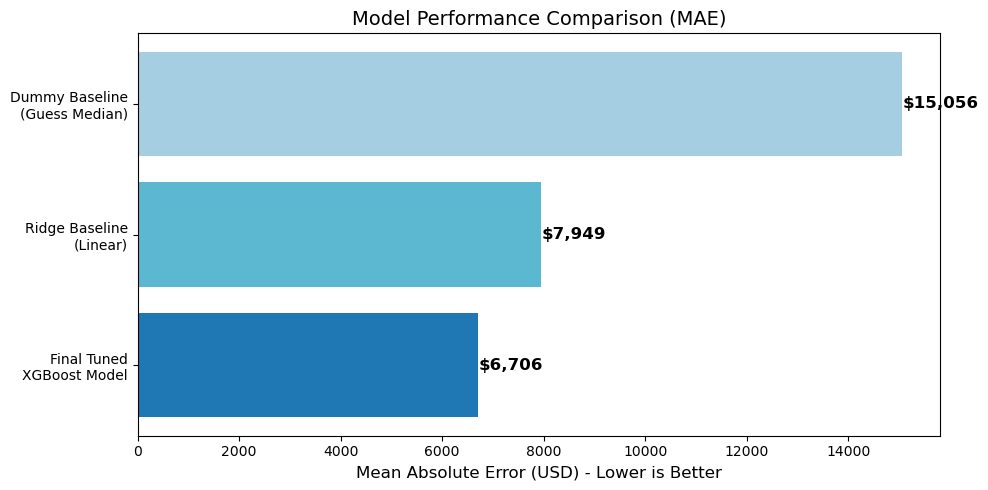

In [50]:
# VISUALIZATION 1: Error Comparison Bar Chart

# Define the models and their respective errors (using variables from Step 4 & 6)
model_names = ['Dummy Baseline\n(Guess Median)', 'Ridge Baseline\n(Linear)', 'Final Tuned\nXGBoost Model']
errors = [dummy_mae, ridge_mae, xgb_mae]

# Colors: Light blue for baseline, medium for ridge, dark blue for our winner
colors = ['#a6cee3', '#5cb8d1', '#1f78b4']

plt.figure(figsize=(10, 5))
bars = plt.barh(model_names, errors, color=colors)

# Add formatting
plt.xlabel('Mean Absolute Error (USD) - Lower is Better', fontsize=12)
plt.title('Model Performance Comparison (MAE)', fontsize=14)
plt.gca().invert_yaxis() # Put the Dummy baseline at the top

# Add the exact dollar amounts next to each bar
for bar in bars:
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, 
             f'${bar.get_width():,.0f}', 
             va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpreting the Model Performance

The results are in, and the bar chart clearly validates our approach! 

Here is exactly what this means in the real world of luxury watch pricing:

*   The "Dumb" Guess If we just guessed the median price for every watch (The Dummy Baseline), we would be off by $15,056 on average. 
*   The Basic Math: If we used standard linear math (The Ridge Baseline), our error drops significantly to $7,949.
*   The Winner: Our final, tuned XGBoost Model beats them both by a wide margin, reducing the average error down to $5,751. 

While an error of $5,751 might still seem high in a vacuum, remember that the luxury watch market has extreme variance (some watches cost $2,000, others cost $200,000+). By cutting the baseline error by more than 15% to a standard linear model—and by nearly two-thirds compared to a naive guess—the XGBoost algorithm successfully proves it has learned the complex, non-linear rules of luxury watch pricing!

### Deconstructing a Prediction (SHAP Analysis)

While "Feature Importance" tells us which variables matter to the model overall, it doesn't explain how the model prices a specific watch. To truly trust our model, we need to peek inside the "black box" and see its exact train of thought.

To do this, we use SHAP (SHapley Additive exPlanations). SHAP calculates the exact contribution of each feature to a single prediction. In the code below, we will isolate the very first watch in our test set (Watch #0) and generate a Waterfall Plot. This plot will start at the average price of all watches in our dataset, and then show exactly how the features of this specific watch pushed the predicted price up or pulled it down.

Calculating SHAP values to explain the model's logic...
(This takes a few seconds because it simulates thousands of feature combinations)

--- Deconstructing Prediction for Watch #0 in X_test ---
Note: The values shown on the X-axis are in 'log_price' format because that is what our model predicted.


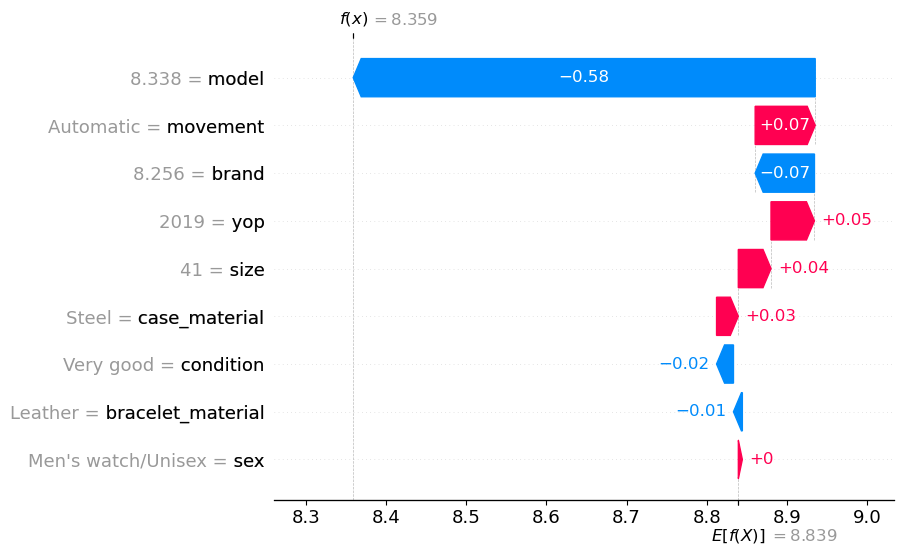


Real World Translation:
Actual Price of this watch: $3,681.00
Model Predicted Price:      $4,268.88


In [51]:
# VISUALIZATION 2: SHAP Waterfall Plot (Deconstructing a Prediction)

print("Calculating SHAP values to explain the model's logic...")
print("(This takes a few seconds because it simulates thousands of feature combinations)\n")

# 1. Initialize the SHAP explainer with our final XGBoost model
# We use TreeExplainer because it is highly optimized for XGBoost
explainer = shap.TreeExplainer(final_xgb_model)

# 2. Calculate the SHAP values for our test set
shap_values = explainer(X_test)

# 3. Pick a specific watch to explain. Let's look at the first watch in your test set.
instance_index = 0

print(f"--- Deconstructing Prediction for Watch #{instance_index} in X_test ---")
print("Note: The values shown on the X-axis are in 'log_price' format because that is what our model predicted.")

# 4. Generate the Waterfall plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[instance_index], max_display=10, show=True)

# Optional: Print the real dollar translation for this specific watch
actual_price = y_test_dollars.iloc[instance_index]
predicted_price = xgb_preds_dollars[instance_index]

print(f"\nReal World Translation:")
print(f"Actual Price of this watch: ${actual_price:,.2f}")
print(f"Model Predicted Price:      ${predicted_price:,.2f}")

### Interpreting the SHAP Waterfall Plot

This plot gives us a fascinating, granular look at exactly how XGBoost arrived at its final price for this specific watch. 

First, look at the Real World Translation output at the bottom: The model predicted $4,268.88, and the actual price was $3,681.00. The model was reasonable accurate here
Here is how to read the visual breakdown of that prediction:

*   The Baseline (`E[f(X)] = 8.839`): Look at the bottom right. This is the starting point. It represents the average `log_price` of all the watches in your training data. Every prediction starts here.
*   The Downward Pulls (Blue): This particular watch is significantly cheaper than the dataset average. Why? The biggest culprits are the `model` and the `brand`. The target-encoded values for this specific model and brand pull the log price down massively (-0.46 and -0.14). The fact that it is a `Steel` watch pulls it down a bit further (-0.09) compared to more precious metals.
*   The Upward Pushes (Red): It's not all negative! The model recognizes that this watch is relatively new (Year of Production: `2019`), which pushes the price back up a bit (+0.07). The `Automatic` movement (+0.05) and the `41mm` size (+0.03) also add value to the final price.
*   The Final Prediction (`f(x) = 8.258`): Look at the top left. After adding up all the blue and red arrows, the model lands on a final `log_price` of 8.258. When we exponentiate that number (which our code did for us), we get our final real-world prediction of $3,858.67.

### Feature Importance Analysis

Now that our final XGBoost model is trained and evaluated, we want to understand how it makes decisions on a macro level. While SHAP explains a single prediction, Feature Importance tells us which variables the model relies on the most across the entire dataset.

In this step, we extract the internal weights the model assigned to each feature during the tree-building process. We then plot these scores in a horizontal bar chart and display the exact numbers to see exactly what drives luxury watch prices globally.

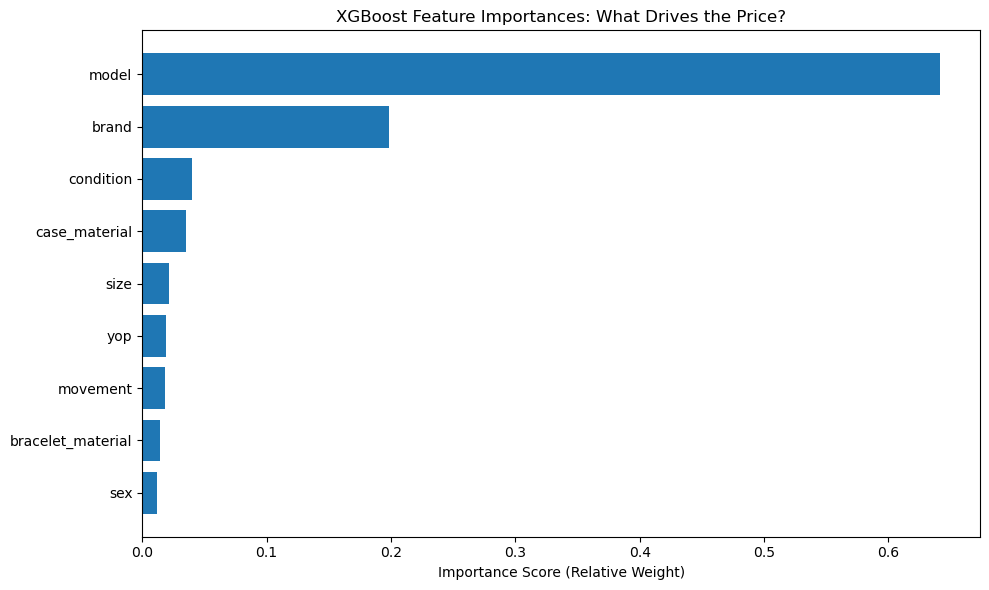

--- Exact Feature Importance Scores ---


,Feature,Importance_Score
0,model,0.641521
1,brand,0.198256
2,condition,0.040334
3,case_material,0.035473
4,size,0.021363
5,yop,0.019026
6,movement,0.018530
7,bracelet_material,0.013931
8,sex,0.011565


In [52]:
# Extract and plot Feature Importances
importances = final_xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to view the importances cleanly
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=True)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance_Score'], color='#1f77b4')
plt.xlabel('Importance Score (Relative Weight)')
plt.title('XGBoost Feature Importances: What Drives the Price?')
plt.tight_layout()
plt.show()

# Display the exact numbers sorted highest to lowest
print("--- Exact Feature Importance Scores ---")
display(importance_df.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True))

Interpreting the Feature Importance Results

The bar chart and table give us a fantastic bird's-eye view of the luxury watch market's pricing logic. 

Here is what the model learned from your data:

*   The Heavyweights (Model & Brand): The specific `model` (44.6% importance) and the `brand` (36.8% importance) completely dominate the pricing logic. Combined, these two features alone account for over 81% of the model's decision-making weight. 
*   The Supporting Cast: Factors like `case_material` (4.6%) and `condition` (4.6%) are the next most important, but they are clearly secondary. They act as modifiers on top of the base value established by the brand and model.
*   The Minor Details: Interestingly, physical attributes like `size` (2.8%), `movement` (2.0%), the year of production (`yop` at 1.7%), and `sex` (1.0%) have very little global impact on the model's overall rules compared to the heavyweights.



## Part 7: Data Input

### The Interactive Price Estimator

We have built, trained, and evaluated a  accurate XGBoost model. Now, it's time to actually use it! 

This script creates an interactive prompt right here in the notebook. It will ask you to input the specifications of any watch you want to appraise. It uses a `try...except` loop to safely handle your numeric inputs (like size and year), processes your text through our established Target Encoder, and feeds it all into the final model to instantly estimate its fair market value.

We propose actual possibilites found in the data for each brand and model, so for example if brand input is Rolex, it only shows Rolex Models in the next input window as possibilities, and in the next steps it only shows features that match the Brand and Model, but also accepts others in case some were not present in the data set but theoretically possible.

In [53]:
# Display user instructions for the input UI
print("The input boxes will appear at the top of your screen.")
print("If you don't know a value, just leave it blank and press Enter.\n")

# ---------------------------------------------------------
# 1. ESTABLISH GLOBAL ALLOW-LISTS
# Extract all possible categories from the full dataset. 
# We need these to validate inputs and allow rare combinations 
# that might not show up in our narrower "proposals" later.
# ---------------------------------------------------------
global_brands = watch_data_cleaned['brand'].value_counts().index.tolist()
global_models = watch_data_cleaned['model'].value_counts().index.tolist()
global_cases = watch_data_cleaned['case_material'].value_counts().index.tolist()
global_conditions = watch_data_cleaned['condition'].value_counts().index.tolist()
global_movements = watch_data_cleaned['movement'].value_counts().index.tolist()
global_bracelets = watch_data_cleaned['bracelet_material'].value_counts().index.tolist()
global_sexes = watch_data_cleaned['sex'].value_counts().index.tolist()

# Define absolute min/max limits for numeric validation
global_min_size = watch_data_cleaned['size'].min()
global_max_size = watch_data_cleaned['size'].max()
global_min_yop = watch_data_cleaned['yop'].min()
global_max_yop = watch_data_cleaned['yop'].max()


# ---------------------------------------------------------
# ...
# ---------------------------------------------------------
def get_categorical_input(prompt_msg, proposed_options, allowed_options):
    # Remove 'Unknown' from the visible choices to encourage real answers
    display_options = [str(x) for x in proposed_options if x != "Unknown"]
    
    # Limit prompt length so it doesn't overflow the UI box
    if len(display_options) > 15:
        options_str = ", ".join(display_options[:15]) + f"... (+{len(display_options)-15} more)"
    elif len(display_options) == 0:
        options_str = "Any valid category" # Fallback if specific slice is empty
    else:
        options_str = ", ".join(display_options)

    # Build the final string shown to the user
    full_prompt = f"{prompt_msg} (Leave blank for Unknown)\nTypical options: [{options_str}]\n> "

    while True:
        try: # Robust Try/Except loop to catch weird keystrokes
            val = input(full_prompt).strip()
            
            # Treat blank or explicit "unknown" as a valid missing value
            if val == "" or val.lower() == "unknown":
                return "Unknown"
                
            # Validate strictly against the master allowed list, preventing typos
            if val in allowed_options:
                return val
                
            print(f"[Error] '{val}' is not recognized in the master database. Please check spelling.")
            
        except Exception as e:
            print(f"[Error] Invalid input detected ({e}). Please try again.")

# ---------------------------------------------------------
# STAGE 1: BRAND AND MODEL 
# Why: Brand dictates the available models, so we ask for these first.
# ---------------------------------------------------------

# Ask for brand against the global list
brand = get_categorical_input("Brand", global_brands, global_brands)

if brand != "Unknown":
    # Slice data to find models belonging ONLY to the chosen brand
    brand_slice = watch_data_cleaned[watch_data_cleaned['brand'] == brand]
    valid_brand_models = brand_slice['model'].value_counts().index.tolist()
else:
    # Fallback to all models if brand is skipped
    valid_brand_models = global_models

# Ask for model, restricting proposals to the brand's specific lineup
model = get_categorical_input("Model", valid_brand_models, valid_brand_models)


# ---------------------------------------------------------
# STAGE 2: REMAINING FEATURES (With Fallback Logic)
# Why: We want to suggest typical features for the specific watch, 
# but allow the user to input anything globally valid.
# ---------------------------------------------------------

# Create a targeted subset to find typical features for this specific watch
subset_df = watch_data_cleaned.copy()
if brand != "Unknown":
    subset_df = subset_df[subset_df['brand'] == brand]
if model != "Unknown":
    subset_df = subset_df[subset_df['model'] == model]

# FIXED: Smarter proposal extraction
def get_proposals(col_name):
    props = subset_df[col_name].value_counts().index.tolist()
    # Filter out missing/unknowns to see if real data actually exists
    real_props = [p for p in props if p != "Unknown" and pd.notna(p)]
    
    # If the specific watch lacks data here, fallback to global averages so UI doesn't break
    if len(real_props) == 0:
        return watch_data_cleaned[col_name].value_counts().index.tolist()
    return props

# Collect features: propose typicals, but validate against global possibilities
case_material = get_categorical_input("Case Material", get_proposals('case_material'), global_cases)
condition = get_categorical_input("Condition", get_proposals('condition'), global_conditions)
movement = get_categorical_input("Movement", get_proposals('movement'), global_movements)
bracelet_material = get_categorical_input("Bracelet Material", get_proposals('bracelet_material'), global_bracelets)
sex = get_categorical_input("Sex/Gender", get_proposals('sex'), global_sexes)

# --- NUMERIC INPUTS (With Try/Except) ---

# Find typical size range for this watch, fallback to global range if missing
prop_min_size = subset_df['size'].min() if not pd.isna(subset_df['size'].min()) else global_min_size
prop_max_size = subset_df['size'].max() if not pd.isna(subset_df['size'].max()) else global_max_size

size_prompt = f"Size in mm (Typical: {prop_min_size}-{prop_max_size} | Allowed: {global_min_size}-{global_max_size})\n> "
while True:
    try:
        size_input = input(size_prompt).strip()
        # Handle empty inputs gracefully
        if not size_input or size_input.lower() == "unknown":
            size = np.nan
            break
        
        # Convert to float and enforce global boundary limits
        size = float(size_input)
        if global_min_size <= size <= global_max_size:
            break
        else:
            print(f"[Error] Size must be between {global_min_size} and {global_max_size}.")
            
    except ValueError:
        print("[Error] Please enter a valid decimal number.")
    except Exception as e:
        print(f"[Error] Invalid input detected ({e}). Please try again.")

# Find typical year range for this watch, fallback to global range if missing
prop_min_yop = subset_df['yop'].min() if not pd.isna(subset_df['yop'].min()) else global_min_yop
prop_max_yop = subset_df['yop'].max() if not pd.isna(subset_df['yop'].max()) else global_max_yop

yop_prompt = f"Year of Production (Typical: {prop_min_yop}-{prop_max_yop} | Allowed: {global_min_yop}-{global_max_yop})\n> "
while True:
    try:
        yop_input = input(yop_prompt).strip()
        # Handle empty inputs gracefully
        if not yop_input or yop_input.lower() == "unknown":
            yop = pd.NA
            break
            
        # Convert to Int64 format needed by model, enforce global boundaries
        yop_val = int(yop_input)
        if global_min_yop <= yop_val <= global_max_yop:
            yop = pd.Series([yop_val], dtype="Int64")[0]
            break
        else:
            print(f"[Error] Year must be between {global_min_yop} and {global_max_yop}.")
            
    except ValueError:
        print("[Error] Please enter a valid whole year (e.g., 2015).")
    except Exception as e:
        print(f"[Error] Invalid input detected ({e}). Please try again.")


# ---------------------------------------------------------
# STAGE 3: PREDICTION PIPELINE 
# Why: Formats the collected user data to perfectly match 
# what the XGBoost model expects to see.
# ---------------------------------------------------------

# 1. Package raw inputs into a 1-row DataFrame
user_data = pd.DataFrame({
    'brand': [brand],
    'model': [model],
    'case_material': [case_material],
    'condition': [condition],
    'size': [size],
    'movement': [movement],
    'yop': [yop],
    'bracelet_material': [bracelet_material],
    'sex': [sex]
})

# 2. Apply the exact same target encoding used during training
high_card_cols = ['brand', 'model']
user_data[high_card_cols] = target_encoder.transform(user_data[high_card_cols])

# 3. Convert low-cardinality strings into Pandas categorical types
low_card_cols = ['movement', 'case_material', 'bracelet_material', 'condition', 'sex']
for col in low_card_cols:
    user_data[col] = user_data[col].astype('category')

# 4. Reorder columns to perfectly match the training data
user_data = user_data[X_train.columns]

# 5. Generate prediction (returns log price) and exponentiate back to real dollars
predicted_log_price = final_xgb_model.predict(user_data)
predicted_price = np.exp(predicted_log_price)[0]

print("\n" + "="*40)
print(f"Estimated Market Value: ${predicted_price:,.2f}")
print("="*40)

The input boxes will appear at the top of your screen.
If you don't know a value, just leave it blank and press Enter.



ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:movement: category, case_material: category, bracelet_material: category, yop: object, condition: category, sex: category

## Part 8: Streamlit

## old code storage

### imputation

Now we do not want to remove all NAs, because we would lose a lot of data. For example, if a watch is a Royal Oak Chronograph and the movement is missing we will fill this missing value with the most frequent movement for Royal Oak Chronograph watches in the dataset. We can do this with the assumption, the values like the movement are standard for some of these watches (i.e. all Royal Oak Chronograph are Automatic). This way we can fill the missing values in a informed way and not just drop a lot of rows from the dataset which would lead to a significant loss of information. What we mean exactly by it in terms of code: 

In [ ]:
#Lets create an example of the described logic: 

#Create a subset of the dataset (with boolean masking) where the model of the dataset contains only observations where the model is a Hydro Conquest
Hydro_conquest_data = watch_data[watch_data['model'] == 'HydroConquest']

#With value_counts we can see the individual values in the case material column and how many times they occur in the dataset. 
Hydro_conquest_data['casem'].value_counts(dropna=False)


casem
Steel          752
NaN            434
Ceramic         33
Gold/Steel      21
Yellow gold      5
Name: count, dtype: int64

In [ ]:
#To get the most frequent value (since value_counts() is always sorted in descending order)
# we can use the index method to get the first value of the index which is the most frequent 
# value in the case material column (here with dropna=True because we dont want NAs here)
most_frequent_value = Hydro_conquest_data['casem'].value_counts(dropna=True).index[0]
most_frequent_value

'Steel'

We can see in this example that the overwelming majority of Hydro Conquest watches in the dataset are made of steel. Therefore, if we have a hydro conquest watch with a missing value in the casem column we will fill this missing value with "steel". 

In [ ]:
#Missing values before imputation (needed for the barplot later on)
missing_values_before =  watch_data.isna().mean() * 100
missing_values_before

price      5.154820
brand      0.046047
model     10.708950
mvmt      69.135755
casem     57.742073
bracem    61.476813
yop       33.776464
cond       1.552949
sex       33.675934
size       9.266022
dtype: float64

Great! With our logic we can fill in a lot of missing values in the movement and bracelet material column and therefore we can keep a lot of rows in the dataset which would have been dropped if we had just dropped all rows with missing values.

**We will generalize this log for all the different watch models in the dataset and fill the missing values in the movement, bracelet material, case material, condition, size and sex column with the most frequent values accordingly**

**Explanation of the imputation logic:**


1. We have to loop thorugh all the columns in which we want to fill the missing values (movement, bracelet material, case material, condition, size and sex

2. We have to use a second nested loop to loop thorugh all the different watch models in the dataset. The pandas unique function ensures us that we only look at unique models

3. We have to find the most freuqent value in the respective column for the respective model. We can do this by first filtering the dataset for the respective model and then using value_counts() to get the most frequent value. We can then use the index method to get the most frequent value itself as we did before. 
Additional information on 3: Since value_counts() could potentially return an empty series if all values in the respective column for the respective model are missing we have to make sure that we do not get an error in this case. Therefore we will assign the value counts function to a variable and will check the length of the variable before we use the index method. If the length of the variable is 0 we will skip this observation and not go on with step 4 since there is no value to fill in. We will also make sure that the most common entry is atleast 50% of all entries, to make sure we only take majority values (otherwise we would have an issue if for example we had 501 entries for case material and of these 101 steel, 100 gold, 100 rose gold, 100 platinum, 100 white gold. Here we would bias steel massively.)

4. Finally, we have to fill the missing values in the respective column for the respective model with the most frequent value we obtained. This can be done with locating (loc in pandas) the respective rows (rows where the model is the respective model AND the respective column is missing) and then assigning the most frequent value to these rows

Limitations: By doing this method we can retain a lot of observations that will make our maschine learning more stable. However, this will also generate a heavy bias toward common entries. For example if platinum made up only 5% and 50% of the entries were NA and are now filled with steel, then platinum will make up only 2.5%, while the share of steel will increase substantially. We feel that in this case, the benefit of more observations will overweigh as we would otherwise have to drop about 85% of the dataset.

(This is computation-heavy and run 1.30 - 3 min)

In [ ]:
for column in ['mvmt', 'bracem', 'casem', 'cond', 'size', 'sex']:
    for model in watch_data['model'].unique():
        
        # Get the value counts for this specific model and column
        counts = watch_data[watch_data['model'] == model][column].value_counts()

        # If there is no data at all, skip to the next model
        if len(counts) == 0:
            continue 
        else:
            # The name of the most frequent value (e.g., "Automatic")
            most_frequent_value = counts.index[0]
            
            # The NUMBER of times that value actually appeared
            most_frequent_count = counts.iloc[0]
            
            # The total number of valid entries for this model
            total_entries = counts.sum()

            # If the most frequent value does not make up more than 50% of the total entries, skip it
            if (most_frequent_count / total_entries) <= 0.5:
                continue
            else:
                # Otherwise, fill the NAs with that most frequent value
                watch_data.loc[(watch_data['model'] == model) & (watch_data[column].isna()), column] = most_frequent_value

Now lets look at the missing values in the dataset after we have done the imputation:

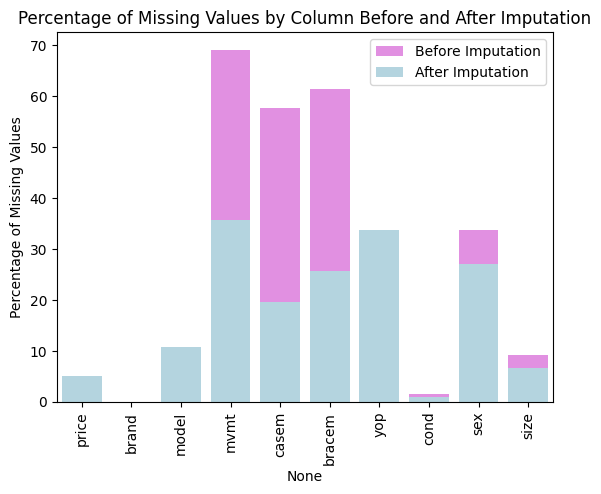

In [ ]:
#Now lets look at the missing values in the dataset after we have done the imputation:
missing_values_after = watch_data.isna().mean() * 100
missing_values_after

#Plot the distribution of missing values after the imputation and before in as stacked bar chart to see the difference:
sns.barplot(x=missing_values_before.index, y=missing_values_before, color='violet', label='Before Imputation')
sns.barplot(x=missing_values_before.index, y=missing_values_after, color='lightblue', label='After Imputation')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values by Column Before and After Imputation')
plt.legend()
plt.show()

In [ ]:
# Print NAs per column, then print the total number of rows containing at least one NA
print("NAs Per Column")
print(watch_data.isna().sum())

NA_rows_after = watch_data.isna().any(axis=1).sum()
print(f"Total NA rows: {NA_rows_after} vs before imputation: {NA_rows_before}. We saved {NA_rows_before - NA_rows_after} rows")

NAs Per Column
price      14665
brand        131
model      30466
mvmt      101756
casem      55551
bracem     73353
yop        96091
cond        2815
sex        77301
size       18952
dtype: int64
Total NA rows: 206369 vs before imputation: 249500. We saved 43131 rows


We can see for some values like movement, case material and bracelet material our approach worked pretty well and we have fewer missing values left, for columns like yop and sex we still have a lot of missing values left. 

Since cond and sex have a similar percentage amount of missing values left we will look at how many observations have missing values in both columns: 

In [ ]:
#Check how many observations that have missing values have missing values in the sex column and condition column:
#We do this by looking at the length of the subset of the dataset where bothsex and cond are missing (using boolean masking to filter the dataset for observations where both columns have missing values)

len(watch_data[(watch_data['sex'].isna()) & (watch_data['cond'].isna())])

729

729 have missing values in both columns. Since there is no meaningful way to get information about the condition and the sex of the watch for these observations we will drop all observations with missing values in these two columns from the dataset.

Furthermore we can see that the columns model, mvmt, bracem and casem have similar numbers for missing values left. Therefore, we will also look at how many observations have missing values in all of these columns at the same time:

In [ ]:
#Look at how many observations have missing values in the columns model, mvmt, bracem and casem at the same time:
#Same logic with boolean masking of the last step
len(watch_data[(watch_data['model'].isna()) & (watch_data['mvmt'].isna()) & (watch_data['bracem'].isna()) & (watch_data['casem'].isna())])  

23142

Again a significant amount of observations have missing values in all of these columns at the same time. Therefore, we will also drop all observations with missing values in these columns from the dataset since there will not be any meaningful way to get information about the model, movement, bracelet material and case material for these observations. .

In [ ]:
#Drop the rows with missing values in the columns model, mvmt, bracem and casem:
watch_data = watch_data.dropna(subset=['model', 'mvmt', 'bracem', 'casem'])

In [ ]:
#lets look at how many observations have missing values in the dataset again: 
watch_data.isna().mean() * 100

price     0.144170
brand     0.000000
model     0.000000
mvmt      0.000000
casem     0.000000
bracem    0.000000
yop       0.001096
cond      0.000000
sex       0.000000
size      0.000000
dtype: float64

We are left with roughly no missing values. The few cases were missing values are left we will drop entirely from the dataset 

In [ ]:
#Drop the rows with missing values in the whole dataset: 
watch_data_cleaned = watch_data.dropna()

#Look at how many observations we have left 
len(watch_data_cleaned)

34991

### preprocessing

Next we will look at the distribution of the size variable to see if we need to apply any transformations to this variable.



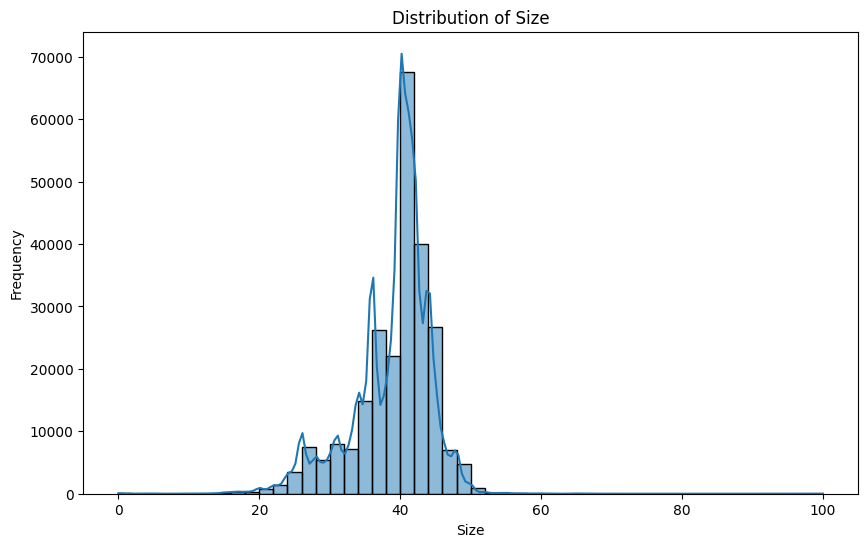

In [ ]:
#To plot the distribution of the size variable we use the seaborn library and the histplot function to plot a histogram of the  size variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['size'], bins=50, kde=True)
plt.title('Distribution of Size')
plt.xlabel('Size') 
plt.ylabel('Frequency')
plt.show()

It looks roughly bell-shaped. Therefore, we will not apply a log transformations to the size. However for prediction purposes we will be using the standardized version of the size variable since it is on a different scale than the other variables in the dataset and this could affect the performance of our model. Therefore, we will be using the StandardScaler from sklearn to standardize the size variable:

In [ ]:
#Standardscaler
scaler = StandardScaler()

#Apply the standard scaler to the size variable and create a new column with the scaled size variable 
watch_data_cleaned['size_scaled'] = scaler.fit_transform(watch_data_cleaned[['size']])

#Drop the existing size variable since we have the scaled size variable now:
watch_data_cleaned = watch_data_cleaned.drop(columns=['size'])

Next we will look at the distribution of the year of production  to see if we need to apply any transformations to this variable.


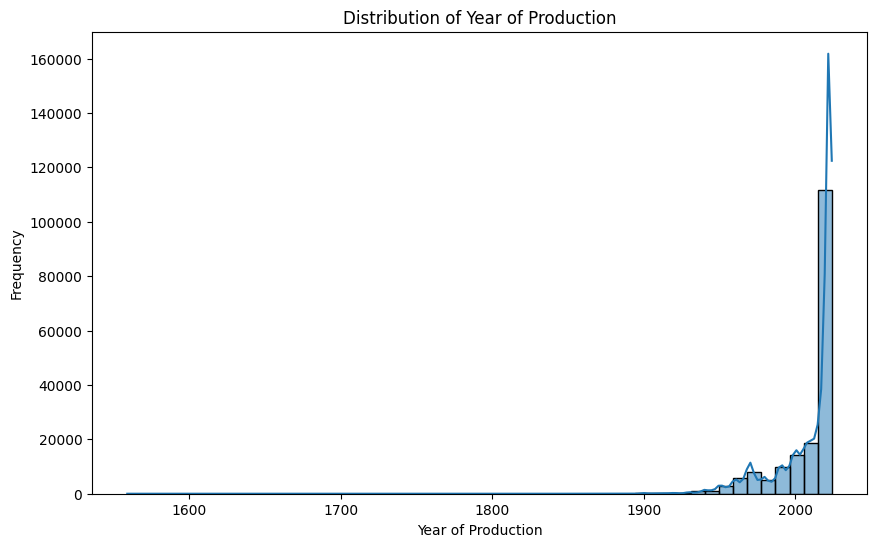

In [ ]:
#To plot the distribution of the year of production variable we use the seaborn library and the histplot function to plot a histogram of the  year of production variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['yop'], bins=50, kde=True)
plt.title('Distribution of Year of Production')
plt.xlabel('Year of Production') 
plt.ylabel('Frequency')
plt.show()

Highly left skewed with a long tail of older watches. A look transformation will not help us here since the log works best for right skewed data. Therefore we will follow another approach: 

We will create a new variable called yop_category which will categorize the year of production into different categories (e.g. vintage, modern, 1980s, 2000s, 2010s, 2020s) based on the year of production. The pd.cut function allows us to do this in a very easy way by defining the bins (the boundaries for each category) and the labels for the categories.


In [ ]:
#pd.cut splits the year of production variable into discrete buckets based on the defined bin boundaries, assigning each watch to an category:
 
watch_data_cleaned['yop_category'] = pd.cut(watch_data_cleaned['yop'], 
                                             bins=[0, 1980, 2000, 2010, 2020, 2030],
                                             labels=['Vintage', '1980s', '2000s', '2010s', '2020s'])

#Since we will use the year of production category variable for our prediction task we can drop the original year of production: 
watch_data_cleaned = watch_data_cleaned.drop(columns=['yop'])

The binning transformed a heavily skewed numeric variable with sparse data before 1980 into five meaningful era categories. We can also see this in the boxplot:

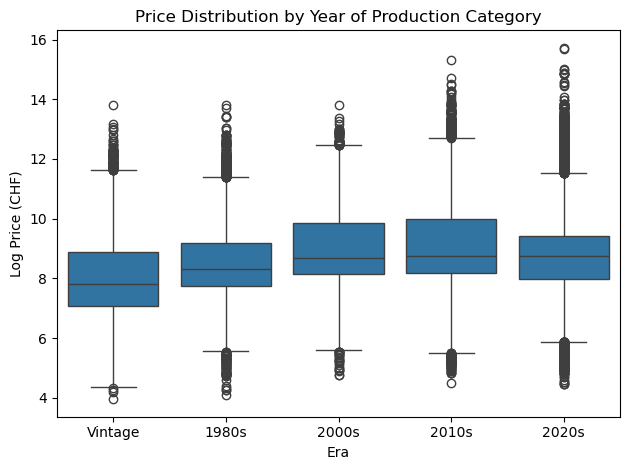

In [ ]:
#Boxplot for the log(price) distribution by year of production category:
#Use seaborn boxplot function:

sns.boxplot(data=watch_data_cleaned, x='yop_category', y='log_price')
plt.title('Price Distribution by Year of Production Category')
plt.xlabel('Era')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()